# Notebook 3: Location Intelligence -->
## 📖 Overview
This notebook focuses on the geographical analysis of road accidents across India. It aims to identify accident-prone states and cities, analyze casualty patterns, and visualize accident hotspots to support data-driven road safety decisions.

## Objectives
- Analyze accident distribution across states and cities.
- Identify accident-prone locations.
- Study casualty patterns across different regions.
- Visualize accident hotspots.
- Generate business insights for road safety planning.

## Business Questions
1. Which states have the highest number of road accidents?
2. Which five states contribute the most road accidents?
3. Which cities report the highest number of road accidents?
4. Which states have the highest average casualties per accident?
5. Is there a relationship between the number of vehicles involved and casualties?
6. How are casualties distributed across all road accidents?
7. Where are road accidents geographically concentrated?

## Dataset Overview
Before performing geographical analysis, let's understand the overall scale of the dataset by examining key statistics such as the total number of accidents, locations, and casualties.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_excel("indian_roads_dataset21.xlsx")

In [3]:
print("Total Accidents :", len(df))
print("Total States :", df["state"].nunique())
print("Total Cities :", df["city"].nunique())
print("Total Casualties :", df["casualties"].sum())

Total Accidents : 20000
Total States : 7
Total Cities : 8
Total Casualties : 34529


# Analysis 1
### Business Question
Which states have the highest number of road accidents?

In [5]:
state_accidents = (df.groupby("state").size().sort_values(ascending=False))
state_accidents

state
Maharashtra    5009
Punjab         2577
Tamil Nadu     2575
West Bengal    2559
Karnataka      2438
Delhi          2433
Telangana      2409
dtype: int64

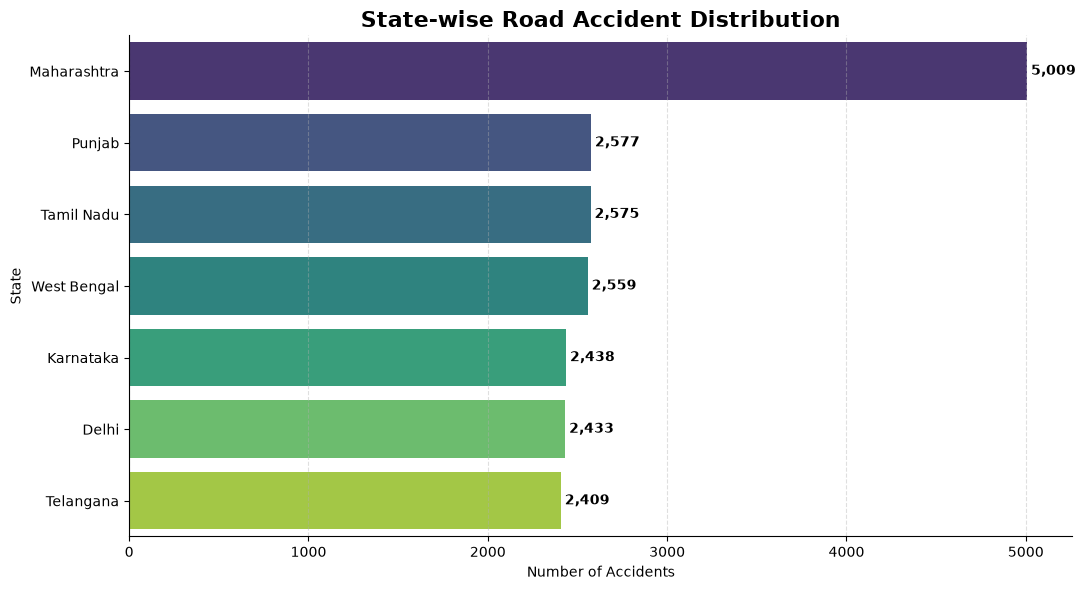

In [6]:
plt.figure(figsize=(11,6))

ax = sns.barplot(
    x=state_accidents.values,
    y=state_accidents.index,
    hue=state_accidents.index,
    palette="viridis",
    legend=False
)

plt.title(
    "State-wise Road Accident Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Accidents")
plt.ylabel("State")

plt.grid(axis="x", linestyle="--", alpha=0.4)

for i, v in enumerate(state_accidents.values):
    ax.text(
        v + 20,
        i,
        f"{v:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Maharashtra records the highest number of road accidents.
- Punjab and Tamil Nadu also report a high number of accidents.
- Accident frequency varies considerably across different states.

### Business Insight
States with consistently high accident counts should be prioritized for stricter traffic monitoring, infrastructure improvements, and road safety awareness campaigns.

# Analysis 2
### Business Question
Which five states contribute the most road accidents?

In [8]:
top5_states = state_accidents.head(5)
top5_df = top5_states.reset_index()
top5_df.columns = ["State", "Accidents"]

In [9]:
fig = px.pie(
    top5_df,
    names="State",
    values="Accidents",
    hole=0.5,
    title="Top 5 Accident-Prone States"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

### Observation
- A significant share of road accidents is concentrated within the top five states.
- Maharashtra contributes the largest proportion among them.
- These states represent the highest-risk regions in the dataset.

### Business Insight
Targeting road safety initiatives in the top five states can have a substantial impact on reducing overall road accidents across the country.

# Analysis 3
### Business Question
Which cities report the highest number of road accidents?

In [10]:
city_accidents = (df.groupby("city").size().sort_values(ascending=False).head(10).reset_index(name="Accidents"))
city_accidents

,city,Accidents
0,Chandigarh,2577
1,Chennai,2575
2,Kolkata,2559
3,Pune,2517
4,Mumbai,2492
5,Bangalore,2438
6,Delhi,2433
7,Hyderabad,2409


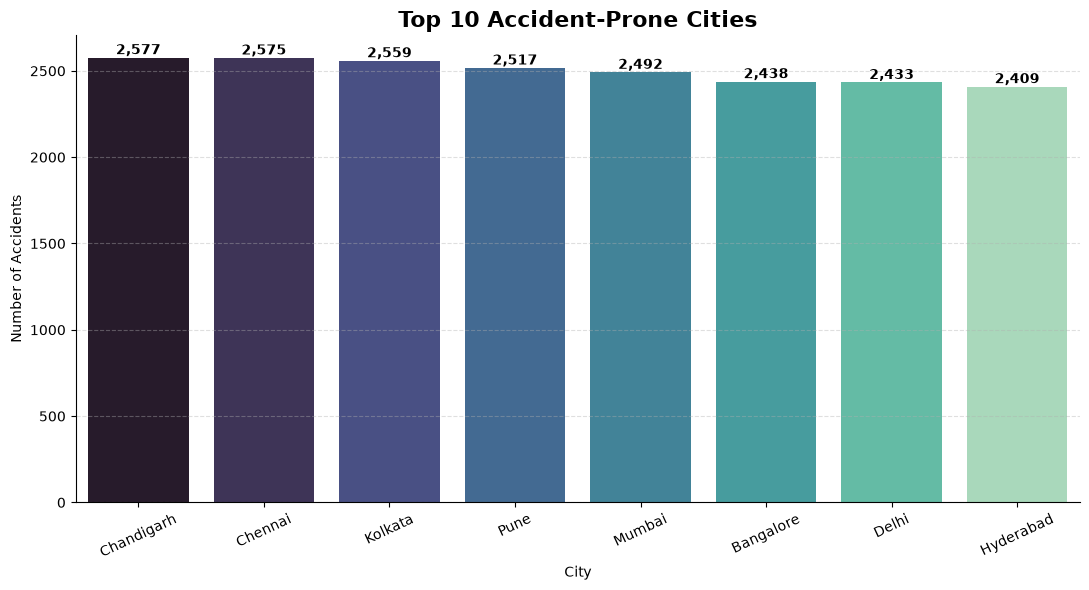

In [11]:
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=city_accidents,
    x="city",
    y="Accidents",
    hue="city",
    palette="mako",
    legend=False
)

plt.title(
    "Top 10 Accident-Prone Cities",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("City")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=25)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for i, v in enumerate(city_accidents["Accidents"]):
    ax.text(
        i,
        v + 20,
        f"{v:,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- The top 10 cities account for a significant number of road accidents.
- Metropolitan and densely populated cities report higher accident frequencies.
- Accident distribution is uneven across different cities.

### Business Insight
Cities with consistently high accident counts should be prioritized for traffic surveillance, road infrastructure improvements, and public safety awareness campaigns.

# Analysis 4
### Business Question
Which states have the highest average casualties per accident?

In [13]:
state_casualties = (df.groupby("state")["casualties"].mean().sort_values(ascending=False).reset_index())
state_casualties

,state,casualties
0,Tamil Nadu,1.773592
1,West Bengal,1.761626
2,Maharashtra,1.740068
3,Delhi,1.715988
4,Punjab,1.698487
5,Karnataka,1.693191
6,Telangana,1.684516


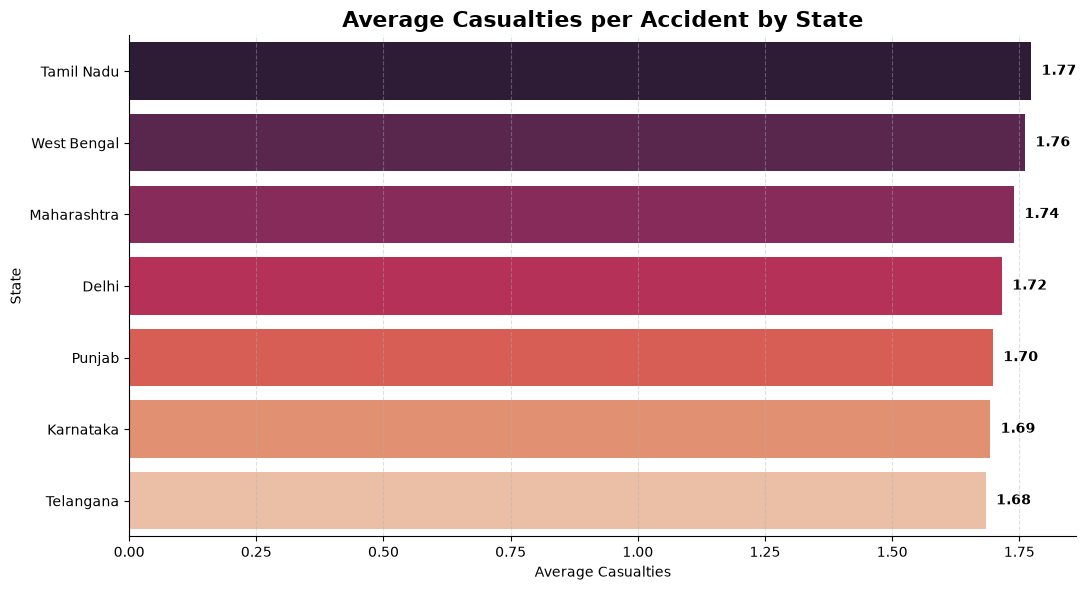

In [14]:
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=state_casualties,
    x="casualties",
    y="state",
    hue="state",
    palette="rocket",
    legend=False
)

plt.title(
    "Average Casualties per Accident by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Casualties")
plt.ylabel("State")

plt.grid(axis="x", linestyle="--", alpha=0.4)

for i, v in enumerate(state_casualties["casualties"]):
    ax.text(
        v + 0.02,
        i,
        f"{v:.2f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Average casualties vary across different states.
- Some states experience fewer accidents but higher average casualties per accident.
- Higher average casualties indicate more severe road accidents.

### Business Insight
Accident severity should be considered alongside accident frequency when planning road safety measures. States with higher average casualties require stronger emergency response systems and improved road safety infrastructure.

# Analysis 5
### Business Question
Is there a relationship between the number of vehicles involved and the number of casualties?

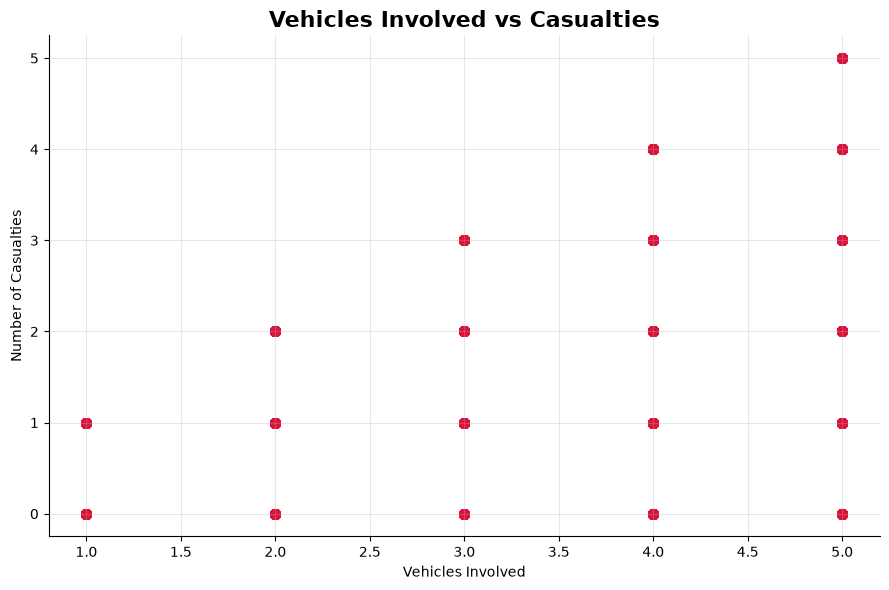

In [15]:
plt.figure(figsize=(9,6))

plt.scatter(
    df["vehicles_involved"],
    df["casualties"],
    color="crimson",
    alpha=0.6,
    s=45
)

plt.title(
    "Vehicles Involved vs Casualties",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Vehicles Involved")
plt.ylabel("Number of Casualties")

plt.grid(alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Accidents involving more vehicles generally tend to result in higher casualties.
- Most accidents involve between two and four vehicles.
- A few accidents have unusually high casualties, indicating severe incidents.

### Business Insight
Multi-vehicle collisions often lead to greater accident severity. Improving traffic management at busy intersections and highways can help reduce such incidents.

# Analysis 6
### Business Question
How are casualties distributed across all road accidents?

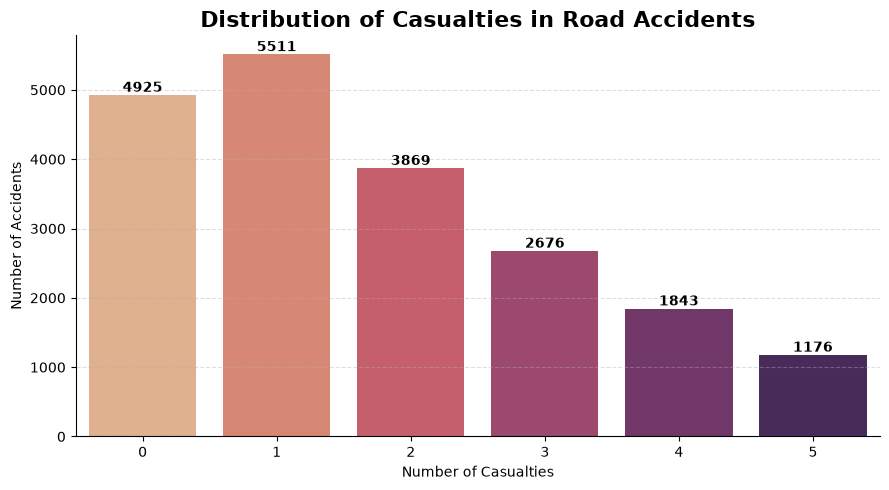

In [16]:
plt.figure(figsize=(9,5))

ax = sns.countplot(
    data=df,
    x="casualties",
    hue="casualties",
    palette="flare",
    legend=False
)

plt.title(
    "Distribution of Casualties in Road Accidents",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Casualties")
plt.ylabel("Number of Accidents")

plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=10,
        fontweight="bold"
    )

sns.despine()

plt.tight_layout()

plt.show()

### Observation
- Most road accidents result in one or two casualties.
- The number of accidents decreases as the casualty count increases.
- Accidents involving four or five casualties are comparatively rare.

### Business Insight
Although accidents with high casualty counts occur less frequently, they have a greater impact on public safety. Preventive measures should focus on reducing accident severity in addition to reducing accident frequency.

# Analysis 7
### Business Question
Where are road accidents geographically concentrated?

In [18]:
fig = px.scatter_map(
    df,
    lat="latitude",
    lon="longitude",
    color="accident_severity",
    size="casualties",
    hover_name="city",
    hover_data=[
        "state",
        "weather",
        "road_type"
    ],
    zoom=4,
    title="Road Accident Hotspots Across India"
)

fig.update_layout(
    margin=dict(
        l=20,
        r=20,
        t=50,
        b=20
    )
)

fig.show()

### Observation
- Road accidents are concentrated in specific regions rather than being evenly distributed.
- Larger markers represent accidents involving more casualties.
- The geographical distribution highlights major accident hotspots.

### Business Insight
Hotspot analysis enables authorities to identify high-risk locations, strengthen traffic monitoring, improve road infrastructure, and optimize emergency response planning.

# Conclusion

This notebook analyzed the geographical distribution of road accidents across India.

The analysis identified accident-prone states and cities, compared average casualties across regions, examined the relationship between vehicles involved and casualties, studied casualty distribution, and visualized accident hotspots. These insights provide valuable support for data-driven road safety planning and strategic decision-making.

# Key Takeaways

- Road accidents are concentrated in a limited number of states and cities.
- Accident severity varies significantly across different regions.
- Multi-vehicle accidents generally result in higher casualties.
- Most accidents involve one or two casualties.
- Geographical hotspot analysis helps identify high-risk locations.
- Location-based insights support better road safety planning and resource allocation.